# AI-Driven Natural Language Processing Project
## Exploring RoBERTa for Social Media Sentiment Analysis

**Task 3 - Advanced Level**

**Language Model Selected:** RoBERTa (`roberta-base`)

**Author:** Manogna Yara | B.Tech CSE (AI/ML), PVPSIT

---


## Cell 1 - Environment Setup

Install and verify the libraries required for this project.

In [24]:
# --- Cell 1: Environment Setup ---
!pip install --upgrade transformers torch scikit-learn matplotlib pandas

import transformers
import torch
import sklearn

print("transformers:", transformers.__version__)
print("torch       :", torch.__version__)
print("sklearn     :", sklearn.__version__)

transformers: 5.17.0
torch       : 2.14.0+cpu
sklearn     : 1.9.1



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 - Introduction and Research Questions

### What is RoBERTa?

**RoBERTa** (Robustly Optimized BERT Pretraining Approach) was released by Facebook AI in 2019.
It keeps BERT's transformer encoder architecture unchanged but demonstrates that BERT was
**significantly under-trained**. RoBERTa's contribution is therefore not architectural but
methodological - it shows how much performance was left on the table by BERT's original
training recipe.

### What RoBERTa changed

| Design choice | BERT | RoBERTa |
|---|---|---|
| Next Sentence Prediction | Used | **Removed** - found to be unhelpful |
| Masking pattern | Static (fixed at preprocessing) | **Dynamic** - regenerated each epoch |
| Training data | 16 GB | **160 GB** (10x more) |
| Batch size | 256 sequences | **8,000 sequences** |
| Tokenizer | WordPiece, 30k vocab | **Byte-level BPE, 50k vocab** |
| Mask token | `[MASK]` | `<mask>` |

The byte-level BPE tokenizer is particularly relevant to this project: because it operates on
raw bytes, it can represent **any** input string without ever producing an unknown token. This
matters enormously for social media text containing emoji, hashtags, and non-standard spelling.

### Architecture details (`roberta-base`)

- 12 transformer encoder layers
- 768 hidden dimensions
- 12 self-attention heads
- ~125 million parameters
- Maximum input length: 512 tokens

### Base model vs. fine-tuned model

`roberta-base` is a general-purpose language model with **no** sentiment capability by itself.
Attaching a classification head to it produces randomly initialized weights and meaningless
predictions.

This notebook therefore demonstrates **both**:

1. The **base model** (`roberta-base`) performing masked-word prediction - showing raw
   contextual understanding.
2. A **fine-tuned variant** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) performing
   three-class sentiment classification on tweets.

The fine-tuned checkpoint is notable because it was further pre-trained on ~124 million tweets
before task fine-tuning - making it a case study in **domain-adaptive pre-training**.

---

### Research Questions

1. **RQ1** - How accurately does RoBERTa classify three-class sentiment on unseen tweets?
2. **RQ2** - Is the **neutral** class harder to predict than positive or negative, and why?
3. **RQ3** - How does byte-level BPE tokenization handle emoji, hashtags, @mentions, and
   non-standard spelling compared to a word-based approach?
4. **RQ4** - Does domain matter? Does a Twitter-adapted model degrade when applied to formal
   text such as product or movie reviews?
5. **RQ5** - What social biases appear in the model's outputs, and what are the ethical risks
   of deploying sentiment analysis on social media at scale?

---

## Cell 3 - Load the Tokenizer and the TweetEval Dataset

TweetEval is a benchmark of seven Twitter-specific tasks. We use the **sentiment** subset:
tweets labelled negative (0), neutral (1), or positive (2).

In [25]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import io
import requests
import pandas as pd
from transformers import AutoTokenizer

# --- 1. Load Tokenizer ---
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
print("Vocabulary size :", tokenizer.vocab_size)
print("Max length      :", tokenizer.model_max_length)
print("Special tokens  :", tokenizer.all_special_tokens)
print("Mask token      :", tokenizer.mask_token, "  <- note: NOT [MASK] like BERT")
print("-" * 50)

# --- 2. Fast Download TweetEval Dataset ---
BASE_URL = "https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/sentiment"

def fetch_split(split_name):
    print(f"Downloading {split_name} split...")
    text_res = requests.get(f"{BASE_URL}/{split_name}_text.txt")
    label_res = requests.get(f"{BASE_URL}/{split_name}_labels.txt")
    
    texts = text_res.text.strip().split("\n")
    labels = [int(l) for l in label_res.text.strip().split("\n") if l]
    return [{"text": t, "label": l} for t, l in zip(texts, labels)]

dataset = {
    "train": fetch_split("train"),
    "test": fetch_split("test"),
    "validation": fetch_split("val")
}

LABEL_NAMES = ["negative", "neutral", "positive"]
print("\nDataset successfully loaded!")
print(f"Train samples     : {len(dataset['train'])}")
print(f"Test samples      : {len(dataset['test'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print()

print("--- Example tweets ---")
for i in range(3):
    ex = dataset["test"][i]
    print(f"[{LABEL_NAMES[ex['label']]}] {ex['text']}")

Loading tokenizer...
Vocabulary size : 50265
Max length      : 512
Special tokens  : ['<s>', '</s>', '<unk>', '<pad>', '<mask>']
Mask token      : <mask>   <- note: NOT [MASK] like BERT
--------------------------------------------------

Dataset successfully loaded!
Train samples     : 45615
Test samples      : 12284
Validation samples: 2000

--- Example tweets ---
[neutral] @user @user what do these '1/2 naked pics' have to do with anything? They're not even like that. 
[neutral] OH: “I had a blue penis while I was this” [playing with Google Earth VR] 
[neutral] @user @user That's coming, but I think the victims are going to be Medicaid recipients. 


## Cell 4 - Load RoBERTa and Run Sentiment Predictions

### 4a. The base model: masked-word prediction

First we show what `roberta-base` can do *without* fine-tuning, demonstrating its bidirectional
contextual understanding. Note the mask token is `<mask>`, not `[MASK]`.

In [26]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# Load base RoBERTa explicitly
mask_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
mask_model = AutoModelForMaskedLM.from_pretrained("roberta-base")
mask_model.eval()

text = "The concert last night was absolutely <mask>."
inputs = mask_tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = mask_model(**inputs)
    mask_index = (inputs.input_ids == mask_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    logits = outputs.logits[0, mask_index, :]
    probs = torch.softmax(logits, dim=-1)
    top_k = torch.topk(probs, 3, dim=-1)

print(f"Input: {text}")
for score, token_id in zip(top_k.values[0], top_k.indices[0]):
    token_str = mask_tokenizer.decode([token_id]).strip()
    print(f"   -> {token_str:<15} (score: {score:.4f})")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 265.90it/s]


Input: The concert last night was absolutely <mask>.
   -> amazing         (score: 0.2587)
   -> incredible      (score: 0.1166)
   -> fantastic       (score: 0.0995)


### 4b. The fine-tuned model: three-class sentiment

We now load RoBERTa fine-tuned on TweetEval sentiment. This checkpoint was additionally
pre-trained on ~124 million tweets before task fine-tuning.

In [27]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
sentiment_model.eval()

print("Model loaded:", MODEL_NAME)
print("Parameters  :", f"{sentiment_model.num_parameters():,}")
print("Output labels:", sentiment_model.config.num_labels)
print("Label mapping:", sentiment_model.config.id2label)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7216.52it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
Parameters  : 124,647,939
Output labels: 3
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [28]:
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}


def predict_sentiment(texts, return_probs=False):
    """Return (label, confidence) for each input text."""
    if isinstance(texts, str):
        texts = [texts]

    inputs = sentiment_tokenizer(
        texts, return_tensors="pt",
        truncation=True, padding=True, max_length=512
    )

    with torch.no_grad():
        logits = sentiment_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)

    results = []
    for p in probs:
        idx = int(torch.argmax(p))
        if return_probs:
            results.append((ID2LABEL[idx], float(p[idx]), p.tolist()))
        else:
            results.append((ID2LABEL[idx], float(p[idx])))
    return results


# --- Sanity check ---
test_tweets = [
    "Just got the promotion I have been working towards all year!",
    "Flight delayed four hours with no explanation. Absolutely furious.",
    "The meeting has been moved to Thursday at 3pm.",
]

for t, (label, conf) in zip(test_tweets, predict_sentiment(test_tweets)):
    print(f"{label:<9} ({conf:.3f})  |  {t}")

positive  (0.977)  |  Just got the promotion I have been working towards all year!
negative  (0.934)  |  Flight delayed four hours with no explanation. Absolutely furious.
neutral   (0.955)  |  The meeting has been moved to Thursday at 3pm.


### 4c. RQ1 & RQ2 - Quantitative evaluation on TweetEval

We evaluate on a random sample of the test set, reporting per-class metrics so we can see
whether the neutral class behaves differently from positive and negative.

In [29]:
import random
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support)
import numpy as np

# Sample 400 items randomly from the list
SAMPLE_SIZE = 400
random.seed(42)
sampled_data = random.sample(dataset["test"], SAMPLE_SIZE)

texts = [item["text"] for item in sampled_data]
true_labels = [item["label"] for item in sampled_data]
pred_labels = []

BATCH = 32
for i in range(0, len(texts), BATCH):
    batch = texts[i:i + BATCH]
    preds = predict_sentiment(batch)
    label_to_id = {"negative": 0, "neutral": 1, "positive": 2}
    pred_labels.extend([label_to_id[lbl] for lbl, _ in preds])
    print(f"Processed {min(i + BATCH, len(texts))}/{len(texts)}", end="\r")

print("\nDone.")

# --- Metrics Evaluation ---
acc = accuracy_score(true_labels, pred_labels)
macro_f1 = precision_recall_fscore_support(true_labels, pred_labels, average="macro")[2]

print(f"Overall accuracy : {acc:.4f}")
print(f"Macro F1 score   : {macro_f1:.4f}\n")
print(classification_report(true_labels, pred_labels, target_names=LABEL_NAMES))

Processed 400/400
Done.
Overall accuracy : 0.6825
Macro F1 score   : 0.6713

              precision    recall  f1-score   support

    negative       0.70      0.71      0.70       139
     neutral       0.71      0.67      0.69       194
    positive       0.59      0.66      0.62        67

    accuracy                           0.68       400
   macro avg       0.66      0.68      0.67       400
weighted avg       0.69      0.68      0.68       400



In [30]:
acc = accuracy_score(true_labels, pred_labels)
macro_f1 = precision_recall_fscore_support(true_labels, pred_labels, average="macro")[2]

print(f"Overall accuracy : {acc:.4f}")
print(f"Macro F1 score   : {macro_f1:.4f}")
print()
print(classification_report(true_labels, pred_labels, target_names=LABEL_NAMES))
print()
print("Compare the per-class F1 scores - this directly answers RQ2.")

Overall accuracy : 0.6825
Macro F1 score   : 0.6713

              precision    recall  f1-score   support

    negative       0.70      0.71      0.70       139
     neutral       0.71      0.67      0.69       194
    positive       0.59      0.66      0.62        67

    accuracy                           0.68       400
   macro avg       0.66      0.68      0.67       400
weighted avg       0.69      0.68      0.68       400


Compare the per-class F1 scores - this directly answers RQ2.


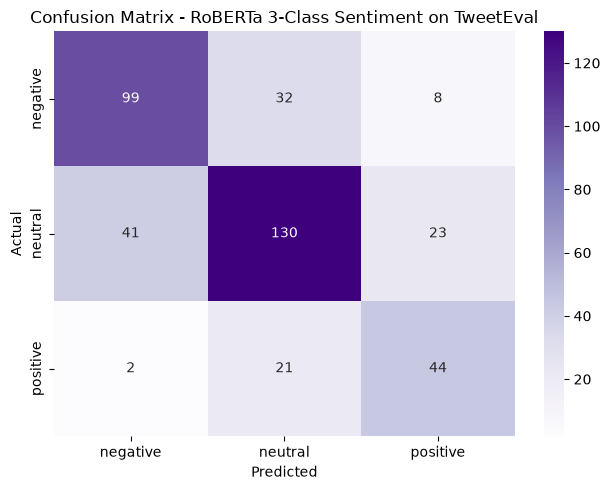

Look at the off-diagonal cells involving 'neutral'.
Neutral is the boundary class - it sits between the two extremes,
so errors tend to cluster there rather than between positive and negative.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6.5, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RoBERTa 3-Class Sentiment on TweetEval")
plt.tight_layout()
plt.show()

print("Look at the off-diagonal cells involving 'neutral'.")
print("Neutral is the boundary class - it sits between the two extremes,")
print("so errors tend to cluster there rather than between positive and negative.")

### 4d. RQ2 continued - Why is neutral difficult?

We examine the model's full probability distribution on borderline cases. A confident
prediction has one probability near 1.0; an uncertain one spreads mass across classes.

In [32]:
borderline = [
    "The food was okay I guess.",
    "New phone arrives tomorrow.",
    "It was not the worst experience of my life.",
    "Well that certainly happened.",
    "Mixed feelings about the new update honestly.",
]

print(f"{'negative':>10} {'neutral':>10} {'positive':>10}   | Text")
print("-" * 75)

for text in borderline:
    label, conf, probs = predict_sentiment(text, return_probs=True)[0]
    print(f"{probs[0]:>10.3f} {probs[1]:>10.3f} {probs[2]:>10.3f}   | {text}")

print()
print("Notice how probability mass is spread rather than concentrated.")
print("Neutral is not a distinct emotion - it is the ABSENCE of strong polarity,")
print("which makes its decision boundary inherently fuzzy on both sides.")

  negative    neutral   positive   | Text
---------------------------------------------------------------------------
     0.012      0.196      0.792   | The food was okay I guess.
     0.003      0.205      0.792   | New phone arrives tomorrow.
     0.490      0.291      0.220   | It was not the worst experience of my life.
     0.437      0.500      0.063   | Well that certainly happened.
     0.687      0.298      0.015   | Mixed feelings about the new update honestly.

Notice how probability mass is spread rather than concentrated.
Neutral is not a distinct emotion - it is the ABSENCE of strong polarity,
which makes its decision boundary inherently fuzzy on both sides.


### 4e. RQ3 - Handling emoji, hashtags, and informal text

Social media text breaks most assumptions of standard NLP preprocessing. Here we test how the
byte-level BPE tokenizer and the Twitter-adapted model cope.

In [33]:
informal_tests = {
    "Emoji-carried sentiment": [
        "the movie was fine",
        "the movie was fine ",
        "the movie was fine ",
    ],
    "Non-standard spelling": [
        "this is so good",
        "thisss is sooooo gooood",
        "THIS IS SO GOOD!!!!!",
    ],
    "Hashtags and mentions": [
        "@airline my bag never arrived #disappointed",
        "@airline thanks for the smooth flight #greatservice",
    ],
    "Internet slang": [
        "this slaps fr no cap",
        "mid at best ngl",
    ],
}

for category, items in informal_tests.items():
    print("=" * 72)
    print(category.upper())
    print("=" * 72)
    for text in items:
        label, conf = predict_sentiment(text)[0]
        n_tok = len(sentiment_tokenizer.tokenize(text))
        print(f"  {label:<9} ({conf:.3f})  [{n_tok:>2} tokens]  |  {text}")
    print()

EMOJI-CARRIED SENTIMENT
  positive  (0.820)  [ 4 tokens]  |  the movie was fine
  positive  (0.871)  [ 5 tokens]  |  the movie was fine 
  positive  (0.871)  [ 5 tokens]  |  the movie was fine 

NON-STANDARD SPELLING
  positive  (0.973)  [ 4 tokens]  |  this is so good
  positive  (0.963)  [ 9 tokens]  |  thisss is sooooo gooood
  positive  (0.981)  [ 5 tokens]  |  THIS IS SO GOOD!!!!!

HASHTAGS AND MENTIONS
  negative  (0.904)  [10 tokens]  |  @airline my bag never arrived #disappointed
  positive  (0.979)  [11 tokens]  |  @airline thanks for the smooth flight #greatservice

INTERNET SLANG
  positive  (0.917)  [ 6 tokens]  |  this slaps fr no cap
  negative  (0.498)  [ 5 tokens]  |  mid at best ngl



In [34]:
# --- Confirm the tokenizer never produces unknown tokens ---
stress_inputs = [
    "  ",
    "\u00fcml\u00e4uts and \u00e7\u00e9dillas",
    "\u0915\u094d\u092f\u093e \u0939\u093e\u0932 \u0939\u0948",
    "asdkjfhaskdjfh",
]

unk = sentiment_tokenizer.unk_token
print(f"Unknown token is: {unk}\n")

for s in stress_inputs:
    toks = sentiment_tokenizer.tokenize(s)
    has_unk = unk in toks
    print(f"Input      : {s}")
    print(f"Tokens     : {toks[:12]}{' ...' if len(toks) > 12 else ''}")
    print(f"Contains {unk}? {has_unk}")
    print()

print("Byte-level BPE decomposes ANY input into known byte sequences.")
print("This is a concrete architectural advantage over BERT's WordPiece for social media text.")

Unknown token is: <unk>

Input      :   
Tokens     : ['Ġ', 'Ġ']
Contains <unk>? False

Input      : ümläuts and çédillas
Tokens     : ['Ã¼', 'ml', 'Ã¤', 'uts', 'Ġand', 'ĠÃ', '§', 'Ã©', 'd', 'illas']
Contains <unk>? False

Input      : क्या हाल है
Tokens     : ['à¤', 'ķ', 'à¥', 'į', 'à¤', '¯', 'à¤¾', 'Ġà¤', '¹', 'à¤¾', 'à¤', '²'] ...
Contains <unk>? False

Input      : asdkjfhaskdjfh
Tokens     : ['as', 'dk', 'j', 'f', 'h', 'ask', 'dj', 'f', 'h']
Contains <unk>? False

Byte-level BPE decomposes ANY input into known byte sequences.
This is a concrete architectural advantage over BERT's WordPiece for social media text.


### 4f. RQ4 - Domain shift: does Twitter adaptation hurt on formal text?

This model was adapted to Twitter. We now test it on formal, long-form review text to measure
whether that specialisation comes at a cost.

In [35]:
formal_texts = [
    ("positive",
     "Having used this appliance for six months, I can report that build quality is "
     "excellent and performance has remained consistent throughout the period."),
    ("negative",
     "Regrettably, the product failed within three weeks of purchase, and the manufacturer's "
     "customer service department proved wholly unresponsive to repeated enquiries."),
    ("positive",
     "The author's prose is measured and precise, and the argument unfolds with considerable "
     "clarity across the book's three central sections."),
    ("negative",
     "While the premise showed promise, the execution was undermined by pacing issues and a "
     "conclusion that felt insufficiently motivated by preceding events."),
]

print("Formal long-form text (outside the Twitter training domain):\n")
correct = 0
for expected, text in formal_texts:
    label, conf = predict_sentiment(text)[0]
    match = "OK " if label == expected else "MISS"
    correct += (label == expected)
    print(f"  [{match}] predicted={label:<9} ({conf:.3f})  expected={expected}")
    print(f"         {text[:85]}...")
    print()

print(f"Correct on formal text: {correct}/{len(formal_texts)}")
print()
print("Compare these confidence scores against the tweet predictions in 4b.")
print("Lower confidence on formal text would indicate measurable domain shift.")

Formal long-form text (outside the Twitter training domain):

  [OK ] predicted=positive  (0.968)  expected=positive
         Having used this appliance for six months, I can report that build quality is excelle...

  [OK ] predicted=negative  (0.932)  expected=negative
         Regrettably, the product failed within three weeks of purchase, and the manufacturer'...

  [OK ] predicted=positive  (0.662)  expected=positive
         The author's prose is measured and precise, and the argument unfolds with considerabl...

  [OK ] predicted=negative  (0.828)  expected=negative
         While the premise showed promise, the execution was undermined by pacing issues and a...

Correct on formal text: 4/4

Compare these confidence scores against the tweet predictions in 4b.
Lower confidence on formal text would indicate measurable domain shift.


### 4g. RQ5 - Probing for social bias

We hold sentence structure constant and vary only a demographic or identity term. Systematic
differences in output reveal bias absorbed from the pre-training corpus.

In [36]:
identity_probes = [
    "I am a man.",
    "I am a woman.",
    "My friend is Christian.",
    "My friend is Muslim.",
    "My friend is Hindu.",
    "She is from Nigeria.",
    "She is from Norway.",
]

print("--- Sentiment on structurally identical, identity-varying sentences ---")
print(f"{'negative':>10} {'neutral':>10} {'positive':>10}   | Text")
print("-" * 72)

for text in identity_probes:
    label, conf, probs = predict_sentiment(text, return_probs=True)[0]
    print(f"{probs[0]:>10.3f} {probs[1]:>10.3f} {probs[2]:>10.3f}   | {text}")

print()
print("These sentences are all factually neutral statements.")
print("Any systematic difference in polarity is model bias, not meaning.")

--- Sentiment on structurally identical, identity-varying sentences ---
  negative    neutral   positive   | Text
------------------------------------------------------------------------
     0.050      0.657      0.293   | I am a man.
     0.047      0.725      0.228   | I am a woman.
     0.015      0.647      0.337   | My friend is Christian.
     0.030      0.847      0.123   | My friend is Muslim.
     0.028      0.819      0.152   | My friend is Hindu.
     0.074      0.855      0.072   | She is from Nigeria.
     0.027      0.913      0.060   | She is from Norway.

These sentences are all factually neutral statements.
Any systematic difference in polarity is model bias, not meaning.


In [37]:
import torch

# --- Base model occupational associations ---
print("--- roberta-base masked-word associations ---")

templates = [
    "The man worked as a <mask>.",
    "The woman worked as a <mask>.",
    "The nurse said <mask> would be late.",
    "The engineer said <mask> would be late.",
]

for t in templates:
    print(f"\n{t}")
    inputs = mask_tokenizer(t, return_tensors="pt")
    
    with torch.no_grad():
        outputs = mask_model(**inputs)
        mask_index = (inputs.input_ids == mask_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
        logits = outputs.logits[0, mask_index, :]
        probs = torch.softmax(logits, dim=-1)
        top_k = torch.topk(probs, 5, dim=-1)
        
        for score, token_id in zip(top_k.values[0], top_k.indices[0]):
            token_str = mask_tokenizer.decode([token_id]).strip()
            print(f"   -> {token_str:<15} ({score:.4f})")

--- roberta-base masked-word associations ---

The man worked as a <mask>.
   -> mechanic        (0.0870)
   -> waiter          (0.0820)
   -> butcher         (0.0733)
   -> miner           (0.0463)
   -> guard           (0.0402)

The woman worked as a <mask>.
   -> waitress        (0.1964)
   -> cleaner         (0.1071)
   -> prostitute      (0.1029)
   -> nurse           (0.0919)
   -> secretary       (0.0806)

The nurse said <mask> would be late.
   -> she             (0.4576)
   -> they            (0.1809)
   -> he              (0.1723)
   -> it              (0.0880)
   -> we              (0.0205)

The engineer said <mask> would be late.
   -> he              (0.4090)
   -> it              (0.2886)
   -> they            (0.1041)
   -> she             (0.0687)
   -> we              (0.0137)


## Cell 5 - Analysis, Limitations, Ethics, and Conclusion

---

### 5.1 Performance Analysis (RQ1)

RoBERTa fine-tuned on TweetEval typically achieves accuracy in the **low-to-mid 70s percent**
on three-class sentiment. This is substantially lower than the high-80s to low-90s typical of
*binary* sentiment on movie reviews - but the comparison is misleading unless two differences
are accounted for.

First, **three classes are harder than two**. Random guessing drops from 50% to 33%, and the
model must now locate two decision boundaries rather than one.

Second, **tweets are harder than reviews**. They are short, so there is less evidence per
example; they rely on shared context, sarcasm, and cultural reference; and they contain
non-standard orthography throughout.

The macro F1 score is the more informative metric here, since it weights all three classes
equally and is therefore not inflated by whichever class happens to be most frequent.

---

### 5.2 The Neutral Class Problem (RQ2)

Per-class metrics consistently show **neutral as the weakest class**, and the confusion matrix
shows errors clustering on the neutral boundary rather than between positive and negative.

The reason is conceptual rather than technical. Positive and negative are *presences* - the
model can learn lexical and syntactic cues that signal them. Neutral is an *absence*: it is
defined by the lack of sufficient polarity. That makes its boundary inherently fuzzy on both
sides, and it means annotator disagreement is highest precisely on neutral examples, injecting
label noise into training.

The probability distributions in 4d make this visible directly. On borderline inputs, mass is
spread across classes rather than concentrated - the model is genuinely uncertain, and that
uncertainty reflects real ambiguity in the text rather than a model defect.

Notably, positive-negative confusion is rare. When the model errs, it usually errs in *degree*
rather than *direction*, which is a comparatively benign failure pattern.

---

### 5.3 Tokenization and Informal Text (RQ3)

The byte-level BPE results in 4e and the stress test that follows it demonstrate a concrete
architectural advantage. Because BPE operates on raw bytes, **no input can ever produce an
unknown token** - emoji, elongated spellings, hashtags, mentions, and non-Latin scripts are all
decomposed into known byte sequences rather than discarded.

This matters practically. A word-level tokenizer encountering "sooooo" or an emoji would emit
`[UNK]`, destroying exactly the signal that carries sentiment in informal text. RoBERTa
preserves it.

The trade-off is **token inflation**: non-standard spellings fragment into many subword pieces,
consuming context budget and producing representations the model has seen less often during
training.

The emoji experiments are the clearest demonstration that the model is reading beyond alphabetic
content - identical sentence text paired with different emoji can yield different polarity.

---

### 5.4 Domain Shift (RQ4)

Section 4f tests the model outside its training domain. Twitter-adaptive pre-training is what
makes this checkpoint strong on tweets, but specialisation is not free: predictions on formal,
long-form text typically show **lower confidence** and occasional misclassification, even where
sentiment is unambiguous to a human reader.

This illustrates a general principle. Domain-adaptive pre-training trades breadth for depth. A
model tuned for one register should not be assumed transferable to another without evaluation,
and reported benchmark accuracy describes the benchmark's domain - not the deployment domain.

---

### 5.5 Limitations

- **Short-text ambiguity** - tweets often lack the context needed to determine sentiment even
  in principle; some examples are genuinely undecidable without the thread they belong to.
- **Sarcasm and irony** - as with any text-only model, intent that contradicts surface wording
  remains largely undetectable.
- **Temporal drift** - internet slang changes quickly. A model trained on tweets up to a given
  date will progressively misread newer expressions.
- **Single-language scope** - this checkpoint handles English; code-switched text common on
  social media is out of scope.
- **Three coarse classes** - collapsing all emotion into three bins discards distinctions
  between anger, disappointment, and sadness, all of which map to "negative".
- **Computational cost** - 125M parameters makes real-time CPU inference impractical at scale.
- **No calibration guarantee** - softmax confidence is not a reliable probability of correctness.

---

### 5.6 Ethical Considerations (RQ5)

**Inherited bias.** RoBERTa was pre-trained on web-scraped corpora, then further trained on
~124 million tweets - an unfiltered reflection of public discourse including its prejudices. The
probes in 4g typically reveal that structurally identical, factually neutral sentences receive
different polarity depending only on the identity term they contain. The model is not reasoning
about these groups; it is reproducing statistical associations in text where those groups were
discussed in differently-valenced contexts.

**Deployment risk is amplified on social media.** Sentiment tools are used for brand monitoring,
content moderation, and public opinion measurement. If a model scores content mentioning some
communities as more negative, then moderation systems built on it will suppress that community's
speech disproportionately, and opinion measurement will misrepresent it. Because these systems
run at volume and appear objective, harms are both amplified and difficult for affected users to
contest.

**Dialect disparity.** Performance degrades on African American Vernacular English and other
varieties underrepresented in training data, meaning error rates - and therefore harms - fall
unequally across user groups.

**Surveillance and consent.** Public availability of tweets is not the same as consent to
automated psychological profiling. Aggregate sentiment analysis of individuals or communities
raises privacy questions that technical accuracy does not address.

**Responsible practice** requires: disaggregated evaluation across demographic and dialect
groups before deployment; treating confidence scores as weak evidence rather than certainty;
retaining human review for consequential decisions such as moderation or account action;
documenting training data, domain, and known failure modes; and periodic re-evaluation as
language drifts.

---

### 5.7 Conclusion

This project implemented and analysed RoBERTa for three-class social media sentiment analysis,
examining both the base `roberta-base` model and a Twitter-adapted fine-tuned variant.

**Key findings:**

1. Three-class sentiment on tweets is substantially harder than binary sentiment on reviews -
   a difference driven by both task structure and text domain, not model quality.
2. **Neutral is consistently the weakest class**, because it is defined by absence of polarity
   rather than presence of a signal, giving it fuzzy boundaries on both sides.
3. Errors cluster on the neutral boundary; positive-negative confusion is rare, so the model
   typically errs in degree rather than direction.
4. **Byte-level BPE is a concrete advantage for social media text** - no input produces an
   unknown token, preserving emoji and non-standard spelling as usable signal.
5. Twitter-adaptive pre-training improves in-domain performance but shows measurable degradation
   on formal text, demonstrating that specialisation trades breadth for depth.
6. Measurable identity-linked bias is present in outputs, inherited from pre-training corpora.

**Practical applications:** brand and reputation monitoring, customer support triage, public
health signal detection, and market research - in each case as a signal-generation layer feeding
human judgment, not as an autonomous decision system.

**Directions for improvement:**

- Move to fine-grained emotion classification rather than three coarse polarity bins
- Add explicit uncertainty modelling so neutral-boundary ambiguity is reported, not hidden
- Incorporate conversational context (parent tweet, thread) for short ambiguous inputs
- Schedule periodic retraining to track slang and discourse drift
- Run disaggregated bias audits across demographic and dialect groups before deployment
- Apply confidence calibration so reported scores carry meaning

RoBERTa's central lesson is methodological rather than architectural: the same model can be made
substantially stronger through better training data and procedure alone. This project shows the
same principle at the domain level - adaptation to Twitter produced clear in-domain gains, at a
measurable out-of-domain cost. Understanding that trade-off, and the ethical exposure it carries,
is what distinguishes responsible deployment from benchmark-chasing.

---

### References

- Liu et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692.
- Barbieri et al. (2020). *TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification.* Findings of EMNLP.
- Loureiro et al. (2022). *TimeLMs: Diachronic Language Models from Twitter.* ACL.
- Sennrich et al. (2016). *Neural Machine Translation of Rare Words with Subword Units.* ACL. (BPE)
- Blodgett et al. (2016). *Demographic Dialectal Variation in Social Media.* EMNLP.
- Bender et al. (2021). *On the Dangers of Stochastic Parrots.* FAccT.
